# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/'
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every '# TODO' cell before moving to 'technical_indicators.ipynb'.

---

## 0. Install & Import Libraries

In [1]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

import re
import os
import math

print('Libraries imported!')

Libraries imported!


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [2]:
# TODO 1.1 — Define directory paths and create them on disk
BASE_DIR      = Path("D:/Projects/lstm-trading-soc/Week2")
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : D:\Projects\lstm-trading-soc\Week2\data\raw
PROCESSED_DIR: D:\Projects\lstm-trading-soc\Week2\data\processed


In [3]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE = '2015-01-01'    # '2015-01-01'
END_DATE   = None    # None

#Load the market symbols in the readme as dictionary here
MARKET_SYMBOLS = {
    'india':  ['^NSEI', '^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS'],
    'us':     ['^GSPC', '^IXIC', 'SPY', 'AAPL', 'MSFT', 'NVDA', 'TSLA'],
    'crypto': ['BTC-USD', 'ETH-USD'],
    'forex':  ['EURUSD=X', 'JPY=X'],
}

print('Markets :', list(MARKET_SYMBOLS.keys()))
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total')

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 16 total


In [4]:
# TODO 1.3 — Implement safe_symbol()
# Converts a ticker into a filesystem-safe filename stem.
# Rules: drop '^', replace '.' '-' '=' with '_'
# Examples:
#   '^NSEI'       -> 'NSEI'
#   'RELIANCE.NS' -> 'RELIANCE_NS'
#   'BTC-USD'     -> 'BTC_USD'
#   'EURUSD=X'    -> 'EURUSD_X'
def safe_symbol(symbol: str) -> str:
    
    symbol = re.sub(r'^\^(.+)$',r'\1',symbol)
    symbol = re.sub(r'\.|\-|=',r'_',symbol)
    return symbol

# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [5]:
# TODO 3.1 — Implement download_symbol()
# Downloads and cleans OHLCV data for a single ticker.
# Steps inside the function:
#   1. Call yf.download() with auto_adjust=False, progress=False
#   2. Raise ValueError if the result is empty
#   3. Flatten MultiIndex columns: keep only the first level
#      (yfinance sometimes returns a MultiIndex when downloading one symbol)
#   4. Reset the index so 'Date' becomes a regular column
#   5. Lowercase all column names; replace spaces with underscores
#   6. Add a 'symbol' column containing the ticker string

def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download() function
    data = yf.download(symbol,start,end,auto_adjust=False,progress=False)
    ...

    # 2. Raise ValueError for check
    if data.empty:
        raise ValueError('Result is empty.')
    ...

    # 3. Flatten MultiIndex
    data.columns = data.columns.get_level_values(0)
    data.columns.name = None
    ...

    # 4. Reset index
    data = data.reset_index()
    ...

    # 5. Normalise column names
    new_column = []
    for column in data.columns:
        new_column = re.sub(' ', '_', column.lower())
        data.rename(columns={column: new_column}, inplace=True)
    ...

    # 6. Add symbol column
    data['symbol'] = symbol
    ...

    return data

# Quick test
test_df = download_symbol('SPY')
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()

(2868, 8)
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052673,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479126,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541153,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514252,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [6]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
# Use a try/except so one failed ticker does not stop the loop.

for market, symbols in MARKET_SYMBOLS.items():
    for symbol in symbols:
        try:
            df = download_symbol(symbol)
            symbol = safe_symbol(symbol)
            print(symbol) 
            file_name = symbol.lower()+".csv"
            df.to_csv(os.path.join(RAW_DIR,file_name),index=False)
            
        except Exception as e:
           print("Error!")
           print("Could not download "+ safe_symbol(symbol) +" in the " + market + " market")
        


NSEI
BSESN
RELIANCE_NS
TCS_NS
INFY_NS
GSPC
IXIC
SPY
AAPL
MSFT
NVDA
TSLA
BTC_USD
ETH_USD
EURUSD_X
JPY_X


---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [7]:
# TODO 4.1 — Load SPY (or any symbol you like) from RAW_DIR
# Parse 'date' as datetime, sort ascending.

df = pd.read_csv(os.path.join(RAW_DIR,'nvda.csv'))
df["date"] = pd.to_datetime(df["date"], format='%Y-%m-%d')
df.sort_values(by='date')
df.set_index('date')
print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2868, 8)
Dtypes:
 date         datetime64[us]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol                  str
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,0.482985,0.50325,0.50700,0.49525,0.50325,113680000,NVDA
1,2015-01-05,0.474828,0.49475,0.50475,0.49250,0.50325,197952000,NVDA
2,2015-01-06,0.460432,0.47975,0.49600,0.47925,0.49550,197764000,NVDA
3,2015-01-07,0.459232,0.47850,0.48750,0.47700,0.48325,321808000,NVDA
4,2015-01-08,0.476507,0.49650,0.49950,0.48375,0.48400,283780000,NVDA


In [8]:
# TODO 4.2 — Compute and print the following statistics
#   1. Mean daily return (pct_change of close)
#   2. Daily return standard deviation (volatility)
#   3. Annualised volatility  →  daily_std * sqrt(252)
#   4. Total cumulative return over the full period
#   5. Date of the all-time high close
#   6. Date of the all-time low close

df['daily_return'] = df['close'].pct_change()
daily_std = df['close'].std()
ann_vol = daily_std*math.sqrt(252)
cum_return = (df['close'].iloc[-1] - df['close'].iloc[0])*100/df['close'].iloc[0]

all_time_high = df.loc[df['close'].idxmax(),'date']
all_time_low = df.loc[df['close'].idxmin(),'date']

print('1. Mean daily return (pct_change of close)')
display(df.head())
print(
  '2. Daily return standard deviation (volatility) ', daily_std,'\n'
  '3. Annualised volatility  →  daily_std * sqrt(252) ', ann_vol,'\n'
  '4. Total cumulative return over the full period ',cum_return,'\n'
  '5. Date of the all-time high close',all_time_high,'\n'
  '6. Date of the all-time low close',all_time_low,'\n'
  )

close   = df['close']

# print(...)

1. Mean daily return (pct_change of close)


,date,adj_close,close,high,low,open,volume,symbol,daily_return
0,2015-01-02,0.482985,0.50325,0.50700,0.49525,0.50325,113680000,NVDA,NaN
1,2015-01-05,0.474828,0.49475,0.50475,0.49250,0.50325,197952000,NVDA,-0.016890
2,2015-01-06,0.460432,0.47975,0.49600,0.47925,0.49550,197764000,NVDA,-0.030318
3,2015-01-07,0.459232,0.47850,0.48750,0.47700,0.48325,321808000,NVDA,-0.002606
4,2015-01-08,0.476507,0.49650,0.49950,0.48375,0.48400,283780000,NVDA,0.037618


2. Daily return standard deviation (volatility)  57.24101460447 
3. Annualised volatility  →  daily_std * sqrt(252)  908.6729366186634 
4. Total cumulative return over the full period  41855.290251226616 
5. Date of the all-time high close 2026-05-14 00:00:00 
6. Date of the all-time low close 2015-01-07 00:00:00 



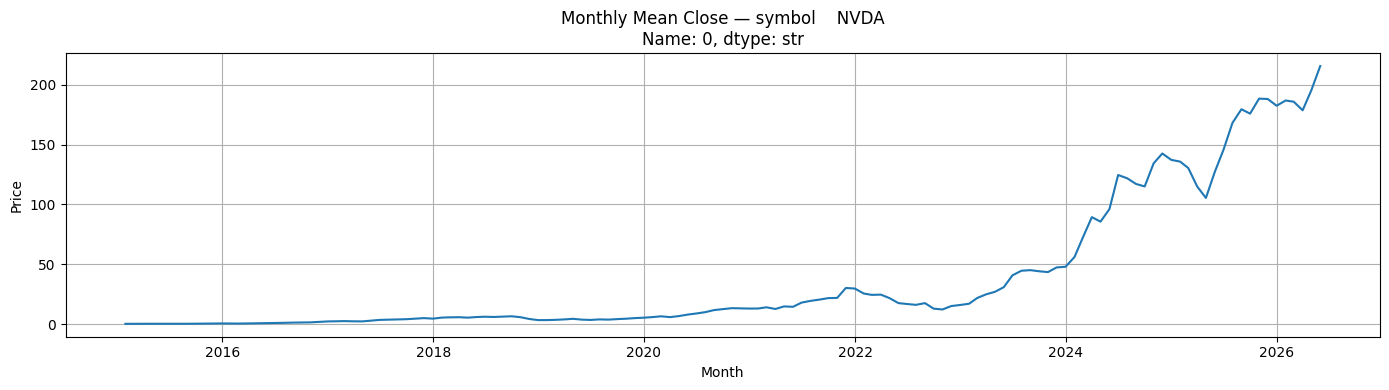

In [9]:
# TODO 4.3 — Resample close to monthly mean and plot as a line chart

 
r = df.set_index('date').resample('ME')
monthly_close = pd.DataFrame([(month_end,group['close'].mean()) for month_end,group in r],columns=['month_end','monthly_average'])
SYMBOL = df.loc[0,['symbol']]
plt.figure(figsize=(14, 4))
plt.plot(monthly_close['month_end'],monthly_close['monthly_average'])
plt.title(f'Monthly Mean Close — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Price')
plt.grid(True); plt.tight_layout(); plt.show()

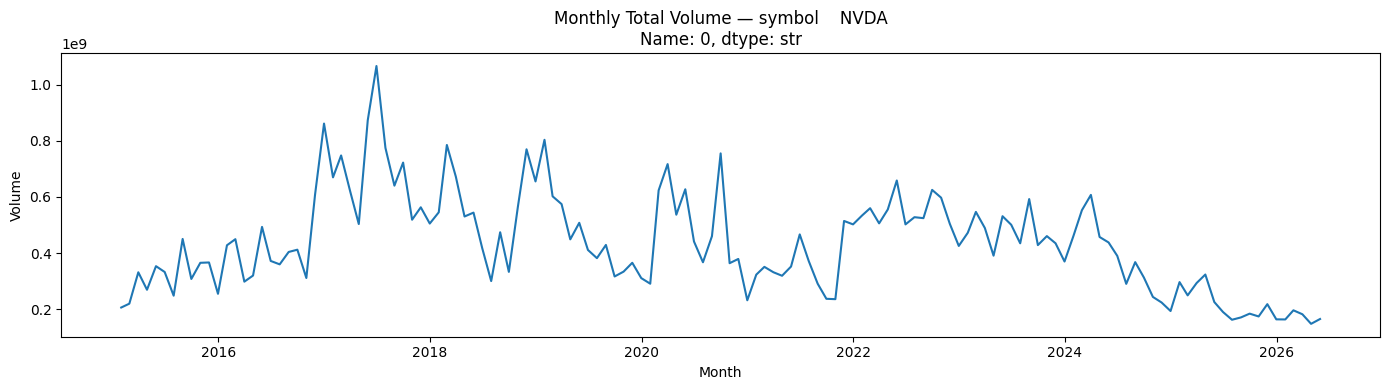

In [10]:
# TODO 4.4 — Resample volume to monthly total and plot as a bar chart

monthly_vol = pd.DataFrame([(month_end,group['volume'].mean()) for month_end,group in r],columns=['month_end','monthly_average'])

plt.figure(figsize=(14, 4))
plt.plot(monthly_vol['month_end'],monthly_vol['monthly_average'])
plt.title(f'Monthly Total Volume — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Volume')
plt.tight_layout(); plt.show()

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [11]:
# TODO 5.1 — Load the Close price for all US symbols into one DataFrame
# Each column = one symbol. Align on date index, forward-fill any gaps.

us_closes = pd.DataFrame()
for sym in MARKET_SYMBOLS['us']:
    sym = safe_symbol(sym)
    file_name = sym.lower()+".csv"
    df = pd.read_csv(os.path.join(RAW_DIR,file_name))
    df.set_index('date',inplace=True)
    us_closes = us_closes.join(df['close'].rename(sym),how='outer')
    ...
us_closes.reset_index(inplace=True)
us_closes["date"] = pd.to_datetime(us_closes["date"],format='%Y-%m-%d')
display(us_closes)

,date,GSPC,IXIC,SPY,AAPL,MSFT,NVDA,TSLA
0,2015-01-02,2058.199951,4726.810059,205.429993,27.332500,46.759998,0.503250,14.620667
1,2015-01-05,2020.579956,4652.569824,201.720001,26.562500,46.330002,0.494750,14.006000
2,2015-01-06,2002.609985,4592.740234,199.820007,26.565001,45.650002,0.479750,14.085333
3,2015-01-07,2025.900024,4650.470215,202.309998,26.937500,46.230000,0.478500,14.063333
4,2015-01-08,2062.139893,4736.189941,205.899994,27.972500,47.590000,0.496500,14.041333
...,...,...,...,...,...,...,...,...
2863,2026-05-22,7473.470215,26343.970703,745.640015,308.820007,418.570007,215.330002,426.010010
2864,2026-05-26,7519.120117,26656.179688,750.590027,308.329987,416.029999,214.860001,433.589996
2865,2026-05-27,7520.359863,26674.730469,750.460022,310.850006,412.670013,212.600006,440.359985
2866,2026-05-28,7563.629883,26917.470703,754.599976,312.510010,426.989990,214.250000,442.100006


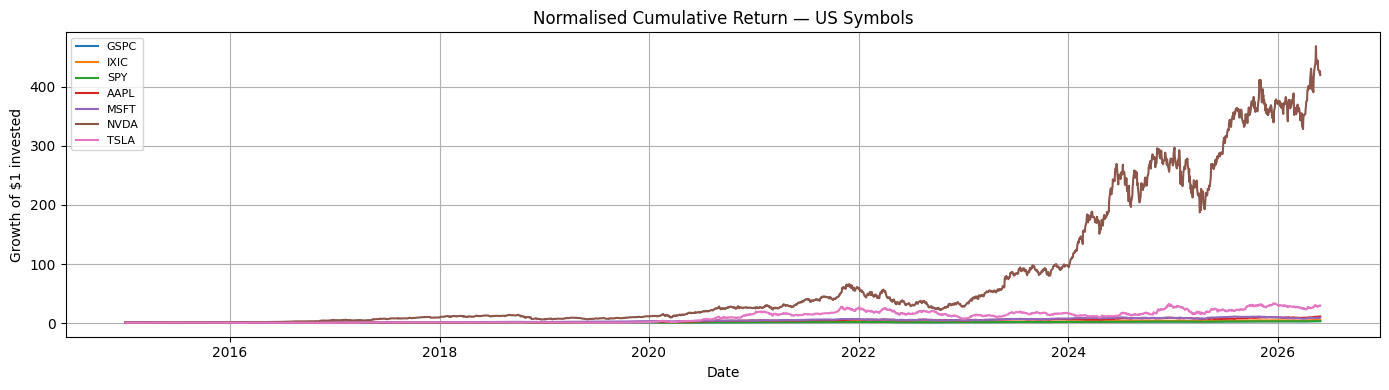

In [12]:
# TODO 5.2 — Normalise so each series starts at 1.0, then plot all on one chart
plt.figure(figsize=(14, 4))
for sym in MARKET_SYMBOLS['us']:
    sym = safe_symbol(sym)
    us_closes[sym] = us_closes[sym]/us_closes[sym].iloc[0]
    plt.plot(us_closes['date'],us_closes[sym],label=sym)
...

plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

,date,NSEI,BSESN,RELIANCE_NS,TCS_NS,INFY_NS
0,2015-01-01,NaN,NaN,202.959000,1272.775024,493.600006
1,2015-01-02,8395.450195,27887.900391,202.421829,1289.724976,503.299988
2,2015-01-05,8378.400391,27842.320312,200.204575,1270.125000,498.975006
3,2015-01-06,8127.350098,26987.460938,191.118393,1223.300049,488.549988
4,2015-01-07,8102.100098,26908.820312,195.278610,1208.849976,490.887512
...,...,...,...,...,...,...
2812,2026-05-25,24031.699219,76488.960938,1367.000000,2308.199951,1168.500000
2813,2026-05-26,23913.699219,76009.703125,1356.300049,2276.199951,1167.699951
2814,2026-05-27,23907.150391,75867.796875,1350.500000,2284.199951,1159.900024
2815,2026-05-28,NaN,NaN,1350.500000,2284.199951,1159.900024


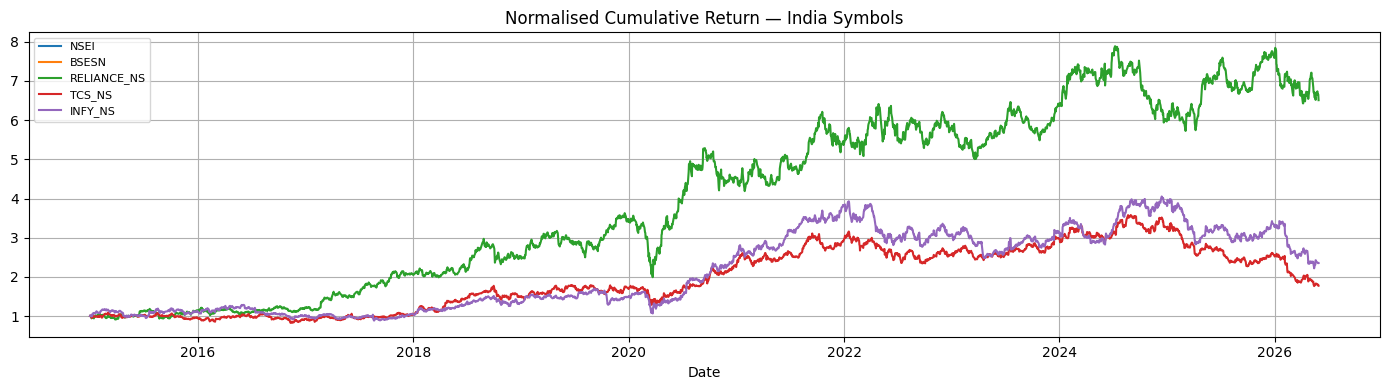

In [13]:
# TODO 5.3 — Repeat for India symbols

india_closes = pd.DataFrame()
for sym in MARKET_SYMBOLS['india']:
    sym = safe_symbol(sym)
    file_name = sym.lower()+".csv"
    df = pd.read_csv(os.path.join(RAW_DIR,file_name))
    df.set_index('date',inplace=True)
    df['close'].rename(sym)
    india_closes = india_closes.join(df['close'].rename(sym),how='outer')
    ...
india_closes.reset_index(inplace=True)
india_closes["date"] = pd.to_datetime(india_closes["date"],format='%Y-%m-%d')
display(india_closes)
# plot normalised series
plt.figure(figsize=(14, 4))
for sym in MARKET_SYMBOLS['india']:
    sym = safe_symbol(sym)
    india_closes[sym] = india_closes[sym]/india_closes[sym].iloc[0]
    plt.plot(india_closes['date'],india_closes[sym],label=sym)
plt.title('Normalised Cumulative Return — India Symbols'); plt.xlabel('Date')
plt.tight_layout();plt.legend(fontsize=8);plt.grid(True);plt.show()

---
